In [1]:
!pip install torch torch_geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.5 MB/s eta 0:00:00


In [2]:
## 2025-11-02
## Dung GNN tao NodeEmbedding va GraphEmbedding
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool

# --- 1. CHUẨN BỊ DỮ LIỆU (PyTorch Geometric Data Object) ---

# Định nghĩa các đặc trưng (features) cho 3 nodes
# x: Tensor có kích thước (số_nodes, số_đặc_trưng)
x = torch.tensor([[-1.], [0.], [1.]], dtype=torch.float)

# Định nghĩa các cạnh (edges)
# edge_index: Tensor có kích thước (2, số_cạnh)
# Cạnh (0, 1), (1, 0), (1, 2), (2, 1)
edge_index = torch.tensor([[0, 1, 1, 2],
                           [1, 0, 2, 1]], dtype=torch.long)

# Tạo đối tượng Data
data = Data(x=x, edge_index=edge_index)

print("--- 1. Thông tin Dữ liệu Đồ thị ---")
print(data)
print(f"Số lượng nodes: {data.num_nodes}")
print(f"Số lượng đặc trưng node ban đầu: {data.num_node_features}")

# --- 2. ĐỊNH NGHĨA MÔ HÌNH GNN CHO NODE EMBEDDINGS ---

class GNN_Node_Embed(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # Lớp GCN thứ nhất
        self.conv1 = GCNConv(in_channels, hidden_channels)
        # Lớp GCN thứ hai. Đầu ra chính là Node Embeddings (out_channels = node_embedding_dim)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # Lớp 1: Propagate -> Transform -> Non-linearity -> Regularization
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)

        # Lớp 2: Tính Node Embeddings
        node_embeddings = self.conv2(x, edge_index)
        return node_embeddings

# --- 3. ĐỊNH NGHĨA MÔ HÌNH GNN CHO GRAPH EMBEDDING (Bao gồm Pooling) ---

class GNN_Graph_Embed(GNN_Node_Embed):
    """Kế thừa GNN_Node_Embed và thêm lớp Pooling."""
    def __init__(self, in_channels, hidden_channels, node_embed_dim, graph_embed_dim):
        super().__init__(in_channels, hidden_channels, node_embed_dim)
        # Lớp Linear sau Pooling (tùy chọn) để điều chỉnh kích thước Graph Embedding
        self.lin = torch.nn.Linear(node_embed_dim, graph_embed_dim)

    def forward(self, x, edge_index, batch):
        # 1. Tính Node Embeddings (sử dụng forward của lớp cha)
        node_embeddings = super().forward(x, edge_index)

        # 2. Global Pooling: Gộp Node Embeddings thành một Graph Embedding
        # global_mean_pool: tính trung bình các Node Embeddings trong mỗi đồ thị (được chỉ định bởi tensor 'batch')
        pooled_embedding = global_mean_pool(node_embeddings, batch)

        # 3. Lớp Linear để ra kích thước Graph Embedding cuối cùng
        graph_embedding = self.lin(pooled_embedding)

        return node_embeddings, graph_embedding

# --- 4. KHỞI TẠO VÀ TÍNH TOÁN ---

# Cấu hình kích thước
IN_CHANNELS = data.num_node_features  # 1
HIDDEN_CHANNELS = 16
NODE_EMBED_DIM = 8  # Kích thước Node Embeddings mong muốn
GRAPH_EMBED_DIM = 4 # Kích thước Graph Embedding mong muốn

model = GNN_Graph_Embed(IN_CHANNELS, HIDDEN_CHANNELS, NODE_EMBED_DIM, GRAPH_EMBED_DIM)

# Chuẩn bị tensor 'batch'
# Vì chỉ có 1 đồ thị, tất cả nodes (3 nodes) đều thuộc đồ thị (batch index) 0.
batch = torch.zeros(data.num_nodes, dtype=torch.long)

# Tính toán Embeddings
model.eval() # Đặt mô hình ở chế độ đánh giá
with torch.no_grad():
    node_embeddings_result, graph_embedding_result = model(data.x, data.edge_index, batch)

# --- 5. HIỂN THỊ KẾT QUẢ ---

print("\n--- 2. Node Embeddings (Đầu ra của conv2) ---")
print(f"Kích thước Node Embeddings: {node_embeddings_result.shape} (Số_Nodes, Kích_thước_Embedding_Node)")
print(node_embeddings_result)

print("\n--- 3. Graph Embedding (Đầu ra của Pooling + Linear) ---")
print(f"Kích thước Graph Embedding: {graph_embedding_result.shape} (Số_Đồ_thị, Kích_thước_Embedding_Đồ_thị)")
print(graph_embedding_result)

--- 1. Thông tin Dữ liệu Đồ thị ---
Data(x=[3, 1], edge_index=[2, 4])
Số lượng nodes: 3
Số lượng đặc trưng node ban đầu: 1

--- 2. Node Embeddings (Đầu ra của conv2) ---
Kích thước Node Embeddings: torch.Size([3, 8]) (Số_Nodes, Kích_thước_Embedding_Node)
tensor([[-0.0510,  0.1355,  0.0766, -0.0615,  0.0382,  0.0164, -0.0473,  0.1846],
        [-0.0885,  0.1381, -0.0469, -0.0098,  0.0742,  0.0781, -0.0548,  0.1054],
        [-0.0574,  0.0336, -0.1340,  0.0495,  0.0527,  0.0793, -0.0198, -0.0555]])

--- 3. Graph Embedding (Đầu ra của Pooling + Linear) ---
Kích thước Graph Embedding: torch.Size([1, 4]) (Số_Đồ_thị, Kích_thước_Embedding_Đồ_thị)
tensor([[0.2406, 0.1591, 0.1179, 0.0028]])


In [3]:
# Ghi dau ra vao file nodeEmbedding.txt va graphembedding.txt
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool

# --- 1. CHUẨN BỊ DỮ LIỆU (PyTorch Geometric Data Object) ---

# Định nghĩa các đặc trưng (features) cho 3 nodes
x = torch.tensor([[-1.], [0.], [1.]], dtype=torch.float)

# Định nghĩa các cạnh (edges)
edge_index = torch.tensor([[0, 1, 1, 2],
                           [1, 0, 2, 1]], dtype=torch.long)

# Tạo đối tượng Data
data = Data(x=x, edge_index=edge_index)

print("--- 1. Thông tin Dữ liệu Đồ thị ---")
print(data)

# --- 2. ĐỊNH NGHĨA MÔ HÌNH GNN CHO NODE EMBEDDINGS ---

class GNN_Node_Embed(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        node_embeddings = self.conv2(x, edge_index)
        return node_embeddings

# --- 3. ĐỊNH NGHĨA MÔ HÌNH GNN CHO GRAPH EMBEDDING (Bao gồm Pooling) ---

class GNN_Graph_Embed(GNN_Node_Embed):
    def __init__(self, in_channels, hidden_channels, node_embed_dim, graph_embed_dim):
        super().__init__(in_channels, hidden_channels, node_embed_dim)
        self.lin = torch.nn.Linear(node_embed_dim, graph_embed_dim)

    def forward(self, x, edge_index, batch):
        # 1. Tính Node Embeddings
        node_embeddings = super().forward(x, edge_index)

        # 2. Global Pooling
        pooled_embedding = global_mean_pool(node_embeddings, batch)

        # 3. Lớp Linear
        graph_embedding = self.lin(pooled_embedding)

        return node_embeddings, graph_embedding

# --- 4. KHỞI TẠO VÀ TÍNH TOÁN EMBEDDINGS ---

# Cấu hình kích thước
IN_CHANNELS = data.num_node_features
HIDDEN_CHANNELS = 16
NODE_EMBED_DIM = 8
GRAPH_EMBED_DIM = 4

model = GNN_Graph_Embed(IN_CHANNELS, HIDDEN_CHANNELS, NODE_EMBED_DIM, GRAPH_EMBED_DIM)

# Tensor 'batch'
batch = torch.zeros(data.num_nodes, dtype=torch.long)

# Tính toán Embeddings
model.eval()
with torch.no_grad():
    node_embeddings_result, graph_embedding_result = model(data.x, data.edge_index, batch)

# --- 5. HIỂN THỊ KẾT QUẢ ---

print("\n--- 2. Node Embeddings ---")
print(f"Kích thước Node Embeddings: {node_embeddings_result.shape}")
print(node_embeddings_result)

print("\n--- 3. Graph Embedding ---")
print(f"Kích thước Graph Embedding: {graph_embedding_result.shape}")
print(graph_embedding_result)

# --- 6. LƯU KẾT QUẢ VÀO FILE TEXT ---

print("\n--- 4. Lưu Embeddings vào File ---")

# Chuyển Tensor sang mảng NumPy để lưu dễ dàng hơn
node_embeddings_np = node_embeddings_result.numpy()
graph_embedding_np = graph_embedding_result.numpy()

# 6.1. Lưu Node Embeddings
node_file_name = "2025-11-01-NodeEmbeddings.txt"
# fmt='%.6f' đảm bảo độ chính xác (6 chữ số thập phân)
# delimiter=' ' sử dụng dấu cách để phân tách các giá trị
try:
    torch.save(node_embeddings_result, 'node_embeddings_tensor.pt')
    with open(node_file_name, 'w') as f:
        # Ghi từng hàng (node embedding)
        for i, row in enumerate(node_embeddings_np):
            # Chuyển các giá trị float thành chuỗi có độ chính xác 6
            row_str = ' '.join([f'{val:.6f}' for val in row])
            f.write(f'Node_{i}: {row_str}\n')

    print(f"✅ Đã lưu Node Embeddings vào file: {node_file_name}")
except Exception as e:
    print(f"❌ Lỗi khi lưu Node Embeddings: {e}")


# 6.2. Lưu Graph Embedding
graph_file_name = "2025-11-01-GraphEmbedding.txt"
try:
    with open(graph_file_name, 'w') as f:
        # Trong trường hợp của chúng ta chỉ có 1 graph embedding
        row = graph_embedding_np[0]
        row_str = ' '.join([f'{val:.6f}' for val in row])
        f.write(f'Graph_Embedding: {row_str}\n')

    print(f"✅ Đã lưu Graph Embedding vào file: {graph_file_name}")
except Exception as e:
    print(f"❌ Lỗi khi lưu Graph Embedding: {e}")

--- 1. Thông tin Dữ liệu Đồ thị ---
Data(x=[3, 1], edge_index=[2, 4])

--- 2. Node Embeddings ---
Kích thước Node Embeddings: torch.Size([3, 8])
tensor([[-0.0139, -0.0849, -0.0275, -0.0351,  0.0751,  0.0731, -0.0262,  0.0832],
        [ 0.0355, -0.0366,  0.0310, -0.0212,  0.1916,  0.0652, -0.0542,  0.0007],
        [ 0.0574,  0.0401,  0.0654,  0.0092,  0.1595,  0.0067, -0.0402, -0.0823]])

--- 3. Graph Embedding ---
Kích thước Graph Embedding: torch.Size([1, 4])
tensor([[-0.2110,  0.1358, -0.0638,  0.2806]])

--- 4. Lưu Embeddings vào File ---
✅ Đã lưu Node Embeddings vào file: 2025-11-01-NodeEmbeddings.txt
✅ Đã lưu Graph Embedding vào file: 2025-11-01-GraphEmbedding.txt


--- 1. Thông tin Dữ liệu Đồ thị (10 Nodes) ---
Data(x=[10, 3], edge_index=[2, 24])
Tổng số cạnh (có hướng): 24


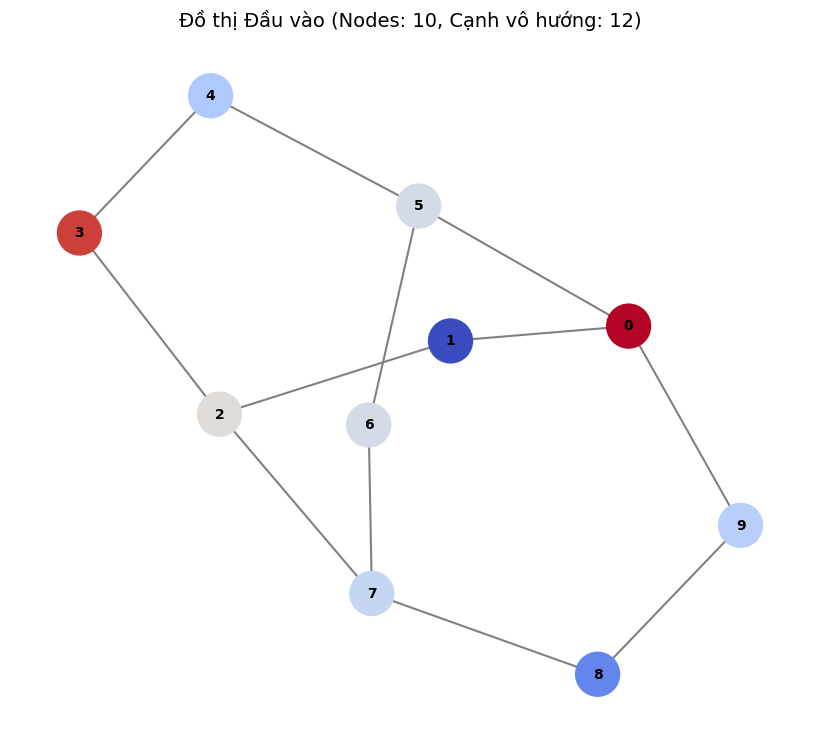


--- 3. Node Embeddings ---
Kích thước Node Embeddings: torch.Size([10, 16])
tensor([[-9.6600e-02,  3.5623e-03, -7.6677e-02,  8.5158e-02,  1.0221e-01,
         -5.9899e-02, -2.5397e-02, -8.4968e-03, -5.7023e-02,  5.5334e-02,
          6.1760e-02,  1.1510e-01,  6.7630e-02, -3.8421e-02,  4.5179e-02,
         -1.8754e-02],
        [ 7.7482e-03,  3.9838e-02, -8.9594e-03,  1.2867e-01,  2.8331e-02,
         -1.1053e-01,  2.7810e-02, -3.9620e-02, -1.1777e-01,  3.8849e-02,
          7.9643e-02, -4.8987e-02,  1.4222e-01, -9.5481e-03,  5.8059e-03,
         -1.7254e-02],
        [-3.9450e-02,  1.2272e-01,  6.3830e-02,  2.7310e-01, -6.3916e-03,
         -2.4033e-01,  3.9305e-02, -1.0491e-01, -3.1472e-01,  5.9135e-02,
          1.1439e-01, -3.1554e-01,  3.2991e-01, -1.5728e-02,  5.0544e-02,
          8.0942e-05],
        [-5.9093e-02,  9.0130e-02,  4.4427e-02,  3.7443e-01, -1.3580e-01,
         -3.8205e-01,  7.2371e-02, -2.1629e-01, -5.5083e-01,  1.1929e-01,
          1.9994e-01, -7.0287e-01,  5.39

In [4]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ====================================================================
# --- CÁC HÀM HỖ TRỢ VÀ MÔ HÌNH ---
# ====================================================================

def draw_graph(data, title="Đồ thị Đầu vào"):
    """Vẽ đồ thị đầu vào bằng NetworkX và Matplotlib."""
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))

    # Thêm các cạnh (chỉ thêm một chiều vì nx.Graph là vô hướng)
    for i in range(data.edge_index.shape[1]):
        u = data.edge_index[0, i].item()
        v = data.edge_index[1, i].item()
        if u < v:
            g.add_edge(u, v)

    # Lấy đặc trưng đầu tiên (cột 0) để tô màu node
    node_colors = 'lightblue'
    if data.x.dim() > 1 and data.x.shape[1] > 0:
        node_colors = data.x[:, 0].numpy()

    plt.figure(figsize=(8, 7))
    pos = nx.spring_layout(g, seed=42)

    nx.draw(g, pos, with_labels=True,
            node_color=node_colors,
            cmap=plt.cm.coolwarm,
            node_size=1000,
            font_size=10, font_weight='bold',
            edge_color='gray', width=1.5)

    plt.title(title, fontsize=14)
    plt.show()

class GNN_Node_Embed(torch.nn.Module):
    """Mô hình GNN cơ bản để tạo Node Embeddings."""
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        node_embeddings = self.conv2(x, edge_index)
        return node_embeddings

class GNN_Graph_Embed(GNN_Node_Embed):
    """Kế thừa GNN_Node_Embed và thêm Global Pooling để tạo Graph Embedding."""
    def __init__(self, in_channels, hidden_channels, node_embed_dim, graph_embed_dim):
        super().__init__(in_channels, hidden_channels, node_embed_dim)
        self.lin = torch.nn.Linear(node_embed_dim, graph_embed_dim)

    def forward(self, x, edge_index, batch):
        # 1. Tính Node Embeddings
        node_embeddings = super().forward(x, edge_index)

        # 2. Global Pooling
        pooled_embedding = global_mean_pool(node_embeddings, batch)

        # 3. Lớp Linear
        graph_embedding = self.lin(pooled_embedding)

        return node_embeddings, graph_embedding

# ====================================================================
# --- KHỞI TẠO, TÍNH TOÁN VÀ LƯU TRỮ ---
# ====================================================================

# --- 1. CHUẨN BỊ DỮ LIỆU (10 Nodes, 12 Cặp Cạnh Vô Hướng) ---

NUM_NODES = 10
IN_CHANNELS = 3
torch.manual_seed(42)
x = torch.randn(NUM_NODES, IN_CHANNELS, dtype=torch.float)

# 12 cặp cạnh vô hướng (24 cạnh có hướng)
edge_list_undirected = torch.tensor([
    [0, 1], [1, 2], [2, 3], [3, 4], [4, 5],
    [5, 6], [6, 7], [7, 8], [8, 9], [9, 0], # Vòng tròn
    [0, 5], [2, 7] # Các cạnh chéo
], dtype=torch.long)

# Tạo edge_index có hướng (kích thước [2, 24])
edge_index = torch.cat([
    edge_list_undirected,
    edge_list_undirected.flip(dims=[1]) # Cạnh ngược lại (v -> u)
], dim=0).t().contiguous()

data = Data(x=x, edge_index=edge_index)

print("--- 1. Thông tin Dữ liệu Đồ thị (10 Nodes) ---")
print(data)
print(f"Tổng số cạnh (có hướng): {data.edge_index.shape[1]}")

# --- GỌI HÀM VẼ ĐỒ THỊ ---
draw_graph(data, f"Đồ thị Đầu vào (Nodes: {data.num_nodes}, Cạnh vô hướng: {data.edge_index.shape[1]//2})")

# --- 2. KHỞI TẠO VÀ TÍNH TOÁN EMBEDDINGS ---

HIDDEN_CHANNELS = 32
NODE_EMBED_DIM = 16
GRAPH_EMBED_DIM = 8

model = GNN_Graph_Embed(IN_CHANNELS, HIDDEN_CHANNELS, NODE_EMBED_DIM, GRAPH_EMBED_DIM)

# Tensor 'batch' (tất cả nodes thuộc đồ thị 0)
batch = torch.zeros(data.num_nodes, dtype=torch.long)

model.eval()
with torch.no_grad():
    node_embeddings_result, graph_embedding_result = model(data.x, data.edge_index, batch)

# --- 3. HIỂN THỊ KẾT QUẢ ---

print("\n--- 3. Node Embeddings ---")
print(f"Kích thước Node Embeddings: {node_embeddings_result.shape}")
print(node_embeddings_result)

print("\n--- 4. Graph Embedding ---")
print(f"Kích thước Graph Embedding: {graph_embedding_result.shape}")
print(graph_embedding_result)

# --- 4. LƯU KẾT QUẢ VÀO FILE TEXT ---

print("\n--- 5. Lưu Embeddings vào File ---")

node_embeddings_np = node_embeddings_result.numpy()
graph_embedding_np = graph_embedding_result.numpy()

# Lưu Node Embeddings
node_file_name = "nodeEmbeddings.txt"
try:
    with open(node_file_name, 'w') as f:
        for i, row in enumerate(node_embeddings_np):
            row_str = ' '.join([f'{val:.6f}' for val in row])
            f.write(f'Node_{i}: {row_str}\n')

    print(f"✅ Đã lưu Node Embeddings vào file: **{node_file_name}**")
except Exception as e:
    print(f"❌ Lỗi khi lưu Node Embeddings: {e}")


# Lưu Graph Embedding
graph_file_name = "GraphEmbedding.txt"
try:
    with open(graph_file_name, 'w') as f:
        row = graph_embedding_np[0]
        row_str = ' '.join([f'{val:.6f}' for val in row])
        f.write(f'Graph_Embedding: {row_str}\n')

    print(f"✅ Đã lưu Graph Embedding vào file: **{graph_file_name}**")
except Exception as e:
    print(f"❌ Lỗi khi lưu Graph Embedding: {e}")

In [ ]:
Tạo ví dụ 10 GNN và lưu trữ lại

In [6]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, global_mean_pool

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ====================================================================
# --- CÁC HÀM HỖ TRỢ VÀ MÔ HÌNH (Tái sử dụng từ ví dụ trước) ---
# ====================================================================

def draw_graph(data, title="Đồ thị Đầu vào"):
    """Vẽ đồ thị đầu vào bằng NetworkX và Matplotlib."""
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))

    # Thêm các cạnh (chỉ thêm một chiều vì nx.Graph là vô hướng)
    # Đảm bảo edge_index không trống trước khi lặp
    if data.edge_index.numel() > 0:
        # Chuyển đổi edge_index thành một tập hợp các tuple để tránh trùng lặp và đảm bảo vô hướng
        undirected_edges = set()
        for i in range(data.edge_index.shape[1]):
            u = data.edge_index[0, i].item()
            v = data.edge_index[1, i].item()
            undirected_edges.add(tuple(sorted((u,v)))) # Thêm dạng chuẩn

        for u, v in undirected_edges:
            g.add_edge(u, v)

    # Lấy đặc trưng đầu tiên (cột 0) để tô màu node
    node_colors = 'lightblue'
    if data.x.dim() > 1 and data.x.shape[1] > 0:
        node_colors = data.x[:, 0].numpy()

    plt.figure(figsize=(8, 7))
    pos = nx.spring_layout(g, seed=42)

    # Xử lý các trường hợp đồ thị rỗng hoặc chỉ có một node
    if g.number_of_nodes() > 0:
        nx.draw(g, pos, with_labels=True,
                node_color=node_colors,
                cmap=plt.cm.coolwarm,
                node_size=1000,
                font_size=10, font_weight='bold',
                edge_color='gray', width=1.5)
    else:
        # Vẽ các node nếu không có cạnh hoặc chỉ có một node
        nx.draw_networkx_nodes(g, pos, node_color=node_colors, node_size=1000)
        nx.draw_networkx_labels(g, pos, font_size=10, font_weight='bold')


    plt.title(title, fontsize=14)
    plt.show()


class GNN_Node_Embed(torch.nn.Module):
    """Mô hình GNN cơ bản để tạo Node Embeddings."""
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        node_embeddings = self.conv2(x, edge_index)
        return node_embeddings

class GNN_Graph_Embed(GNN_Node_Embed):
    """Kế thừa GNN_Node_Embed và thêm Global Pooling để tạo Graph Embedding."""
    def __init__(self, in_channels, hidden_channels, node_embed_dim, graph_embed_dim):
        super().__init__(in_channels, hidden_channels, node_embed_dim)
        self.lin = torch.nn.Linear(node_embed_dim, graph_embed_dim)

    def forward(self, x, edge_index, batch):
        # 1. Tính Node Embeddings
        node_embeddings = super().forward(x, edge_index)

        # 2. Global Pooling
        pooled_embedding = global_mean_pool(node_embeddings, batch)

        # 3. Lớp Linear
        graph_embedding = self.lin(pooled_embedding)

        return node_embeddings, graph_embedding

# ====================================================================
# --- TẠO VÀ CHẠY VÍ DỤ VỚI 10 ĐỒ THỊ ---
# ====================================================================

print("--- Bắt đầu ví dụ với 10 Đồ thị ---")

NUM_GRAPHS = 10
IN_CHANNELS = 3 # Số lượng đặc trưng mỗi node (sẽ cố định)
HIDDEN_CHANNELS = 32
NODE_EMBED_DIM = 16
GRAPH_EMBED_DIM = 8

graphs_list = []

for i in range(NUM_GRAPHS):
    # Tạo một đồ thị ngẫu nhiên
    num_nodes_in_graph = torch.randint(5, 15, (1,)).item() # Số node ngẫu nhiên từ 5 đến 14
    prob_edge = torch.rand(1).item() * 0.5 + 0.1 # Xác suất cạnh ngẫu nhiên từ 0.1 đến 0.6

    # Tạo đồ thị ngẫu nhiên bằng NetworkX
    g_nx = nx.gnp_random_graph(num_nodes_in_graph, prob_edge, seed=i) # Sử dụng seed để có thể tái tạo

    # Nếu đồ thị không có node, bỏ qua
    if num_nodes_in_graph == 0:
        print(f"Cảnh báo: Đồ thị {i+1} có 0 node, bỏ qua.")
        continue

    # Tạo đặc trưng node
    x_graph = torch.randn(num_nodes_in_graph, IN_CHANNELS, dtype=torch.float)

    # Chuyển đổi cạnh từ NetworkX sang PyG
    if g_nx.number_of_edges() > 0:
        edge_index_graph = torch.tensor(list(g_nx.edges()), dtype=torch.long).t().contiguous()
        # Thêm cạnh hai chiều cho đồ thị vô hướng
        edge_index_graph = torch.cat([edge_index_graph, edge_index_graph.flip(0)], dim=1)
    else:
        # Nếu không có cạnh, tạo một tensor rỗng có kích thước [2, 0]
        edge_index_graph = torch.empty((2, 0), dtype=torch.long)


    # Tạo Data object cho từng đồ thị
    data_graph = Data(x=x_graph, edge_index=edge_index_graph)
    graphs_list.append(data_graph)

    # (Tùy chọn) Vẽ một hoặc hai đồ thị để kiểm tra
    # if i < 2:
    #     draw_graph(data_graph, f"Đồ thị Ngẫu nhiên {i+1} (Nodes: {num_nodes_in_graph}, Edges: {g_nx.number_of_edges()})")


if not graphs_list:
    print("Không tạo được đồ thị nào trong danh sách. Vui lòng kiểm tra lại logic tạo đồ thị.")
elif len(graphs_list) != NUM_GRAPHS: # Kiểm tra số lượng đồ thị thực tế được tạo
    print(f"Cảnh báo: Chỉ tạo được {len(graphs_list)}/{NUM_GRAPHS} đồ thị (có thể một số đồ thị có 0 node đã bị bỏ qua)."
          f"Cập nhật NUM_GRAPHS = {len(graphs_list)}")
    # Tiếp tục với các đồ thị đã tạo thành công
    NUM_GRAPHS = len(graphs_list) # Cập nhật số lượng đồ thị để xử lý


if graphs_list: # Chỉ xử lý nếu có đồ thị được tạo
    # --- Gom tất cả đồ thị vào một batch Data object ---
    # PyG's Batch object xử lý việc nối x, edge_index và tạo tensor batch một cách tự động
    batched_data = Batch.from_data_list(graphs_list)

    print(f"\n--- Thông tin Đồ thị Batch (Tổng cộng {len(graphs_list)} đồ thị) ---")
    print(batched_data)
    print(f"Tổng số nodes trong batch: {batched_data.num_nodes}")
    print(f"Tổng số cạnh trong batch: {batched_data.edge_index.shape[1] if batched_data.edge_index.numel() > 0 else 0}")
    print(f"Tensor batch: {batched_data.batch.shape}") # tensor batch ánh xạ các node tới chỉ mục đồ thị

    # --- Khởi tạo và tính toán Embeddings ---
    model = GNN_Graph_Embed(IN_CHANNELS, HIDDEN_CHANNELS, NODE_EMBED_DIM, GRAPH_EMBED_DIM)

    model.eval() # Đặt mô hình ở chế độ đánh giá
    with torch.no_grad():
        node_embeddings_all_graphs, graph_embeddings_results = model(batched_data.x, batched_data.edge_index, batched_data.batch)

    # --- Hiển thị kết quả ---
    print("\n--- Node Embeddings (Từ tất cả các đồ thị) ---")
    print(f"Kích thước Node Embeddings chung: {node_embeddings_all_graphs.shape}") # (Tổng_số_nodes, NODE_EMBED_DIM)
    # print(node_embeddings_all_graphs) # In ra nếu muốn xem toàn bộ

    print("\n--- Graph Embeddings (Mỗi hàng là một đồ thị) ---")
    print(f"Kích thước Graph Embeddings: {graph_embeddings_results.shape}") # (Số_đồ_thị, GRAPH_EMBED_DIM)
    for i, g_embed in enumerate(graph_embeddings_results):
        print(f"Graph {i+1} Embedding: {g_embed.tolist()}")

    # --- Lưu kết quả vào file TEXT (Mỗi đồ thị một file riêng) ---
    print("\n--- Lưu Embeddings vào File (Từng đồ thị riêng biệt) ---")

    node_idx_offset = 0
    for i, graph_data in enumerate(graphs_list):
        num_nodes_current_graph = graph_data.num_nodes

        # 1. Lưu Node Embeddings cho đồ thị hiện tại
        node_file_name = f"graph_{i+1}_node_embeddings.txt"
        try:
            current_graph_node_embeddings = node_embeddings_all_graphs[node_idx_offset : node_idx_offset + num_nodes_current_graph]
            with open(node_file_name, 'w') as f:
                f.write(f"--- Node Embeddings for Graph {i+1} (Nodes: {num_nodes_current_graph}) ---\n")
                for node_j, row in enumerate(current_graph_node_embeddings.numpy()):
                    row_str = ' '.join([f'{val:.6f}' for val in row])
                    f.write(f'Node_{node_j}: {row_str}\n')

            print(f"✅ Đã lưu Node Embeddings của Graph {i+1} vào file: **{node_file_name}**")
        except Exception as e:
            print(f"❌ Lỗi khi lưu Node Embeddings của Graph {i+1}: {e}")

        # 2. Lưu Graph Embedding cho đồ thị hiện tại
        graph_file_name = f"graph_{i+1}_embedding.txt"
        try:
            current_graph_embedding = graph_embeddings_results[i]
            with open(graph_file_name, 'w') as f:
                row_str = ' '.join([f'{val:.6f}' for val in current_graph_embedding.numpy()])
                f.write(f'Graph_{i+1}_Embedding: {row_str}\n')

            print(f"✅ Đã lưu Graph Embedding của Graph {i+1} vào file: **{graph_file_name}**")
        except Exception as e:
            print(f"❌ Lỗi khi lưu Graph Embedding của Graph {i+1}: {e}")

        node_idx_offset += num_nodes_current_graph


--- Bắt đầu ví dụ với 10 Đồ thị ---

--- Thông tin Đồ thị Batch (Tổng cộng 10 đồ thị) ---
DataBatch(x=[109, 3], edge_index=[2, 358], batch=[109], ptr=[11])
Tổng số nodes trong batch: 109
Tổng số cạnh trong batch: 358
Tensor batch: torch.Size([109])

--- Node Embeddings (Từ tất cả các đồ thị) ---
Kích thước Node Embeddings chung: torch.Size([109, 16])

--- Graph Embeddings (Mỗi hàng là một đồ thị) ---
Kích thước Graph Embeddings: torch.Size([10, 8])
Graph 1 Embedding: [0.05495567247271538, 0.09616455435752869, 0.1951514035463333, -0.226867213845253, -0.06371091306209564, 0.2637328505516052, 0.2785145044326782, -0.010369852185249329]
Graph 2 Embedding: [0.0005455967038869858, 0.10897254943847656, 0.18663273751735687, -0.22125934064388275, -0.029692746698856354, 0.1995929479598999, 0.21230018138885498, 0.013135388493537903]
Graph 3 Embedding: [-0.031093474477529526, 0.139936164021492, 0.19317957758903503, -0.1970076709985733, 0.015412461012601852, 0.22027744352817535, 0.2044256180524826, 

Bài toán gom cụm

Đọc tất cả các Graph Embeddings từ các file graph_X_embedding.txt đã lưu.
Gom chúng lại thành một tập dữ liệu duy nhất.
Áp dụng thuật toán gom cụm K-Means để phân nhóm các đồ thị.
Giảm chiều dữ liệu bằng PCA để có thể trực quan hóa các cụm trên biểu đồ 2D.
Hiển thị kết quả gom cụm và trực quan hóa chúng.
Trong ví dụ này, tôi sẽ chọn n_clusters=3 cho K-Means. Bạn có thể thay đổi số lượng cụm này tùy theo mục tiêu phân tích của mình.

Tuyệt vời! Bài toán gom cụm đã được chạy thành công với các Graph Embeddings của 10 đồ thị. Dưới đây là kết quả:

Số lượng Graph Embeddings đã đọc: 10, mỗi embedding có kích thước 8 chiều.

K-Means Clustering: Thuật toán K-Means đã được áp dụng với K=3 (3 cụm).

Kết quả gom cụm: Các đồ thị đã được phân loại vào các cụm như sau:

Cụm 0: Graph 1, Graph 3, Graph 4, Graph 8, Graph 9, Graph 10
Cụm 1: Graph 5, Graph 6
Cụm 2: Graph 2, Graph 7
Trực quan hóa: Để bạn dễ dàng hình dung, các Graph Embeddings 8 chiều đã được giảm xuống còn 2 chiều bằng phương pháp PCA và được vẽ trên biểu đồ. Mỗi điểm trên biểu đồ đại diện cho một đồ thị, và màu sắc của điểm cho biết nó thuộc cụm nào. Các nhãn 'G1', 'G2', ... 'G10' giúp bạn xác định đồ thị cụ thể.

Biểu đồ trực quan hóa hiển thị rõ ràng cách các đồ thị được nhóm lại thành 3 cụm dựa trên sự tương đồng của các Graph Embeddings của chúng. Các đồ thị trong cùng một cụm có đặc điểm cấu trúc hoặc thuộc tính tương tự nhau theo cách mà mô hình GNN đã học được.

--- Bắt đầu bài toán Gom cụm (Clustering) ---

Tìm thấy 10 file Graph Embedding. Đang đọc...

Đã đọc 10 Graph Embeddings với kích thước 8.
Ví dụ về một Graph Embedding:
 [-0.01494   0.1465    0.166245 -0.184962  0.036348  0.191426  0.198001
  0.039663]

Đang thực hiện K-Means với K = 3...

Kết quả gom cụm (Cluster Assignments):
Graph 1 thuộc Cụm 0
Graph 2 thuộc Cụm 2
Graph 3 thuộc Cụm 0
Graph 4 thuộc Cụm 0
Graph 5 thuộc Cụm 1
Graph 6 thuộc Cụm 1
Graph 7 thuộc Cụm 2
Graph 8 thuộc Cụm 0
Graph 9 thuộc Cụm 0
Graph 10 thuộc Cụm 0

Giảm chiều dữ liệu bằng PCA để trực quan hóa...


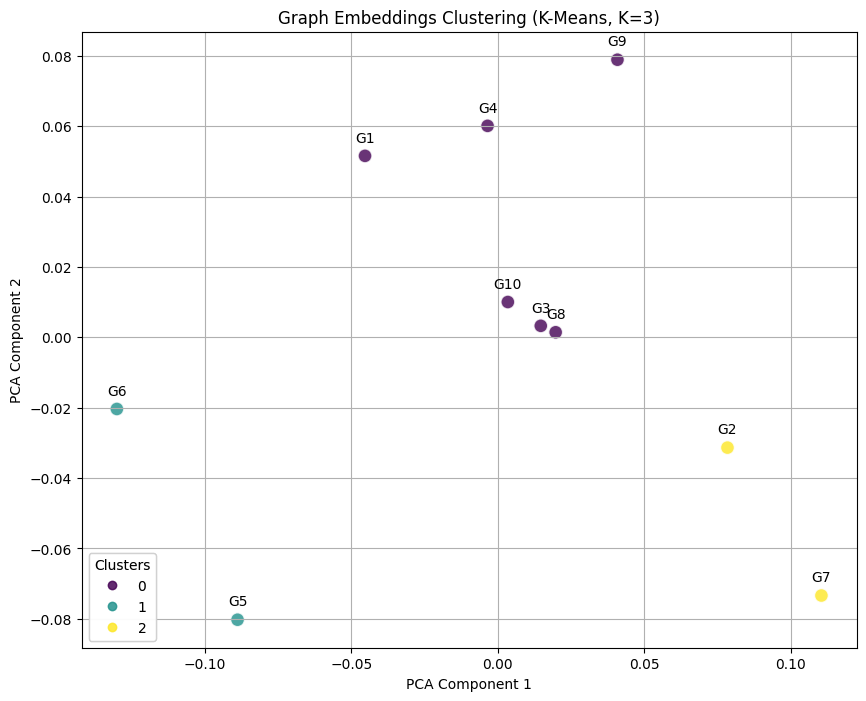


--- Hoàn thành bài toán Gom cụm ---


In [7]:
import numpy as np
import glob
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch # Để đọc lại embeddings nếu cần, nhưng ở đây chúng ta đọc từ file văn bản

print("--- Bắt đầu bài toán Gom cụm (Clustering) ---\n")

# 1. Đọc tất cả các Graph Embeddings từ các file
graph_embeddings_list = []
# Tìm tất cả các file có dạng 'graph_X_embedding.txt'
embedding_files = sorted(glob.glob('graph_*_embedding.txt'))

if not embedding_files:
    print("❌ Không tìm thấy file Graph Embedding nào. Hãy đảm bảo bạn đã chạy cell trước đó.")
else:
    print(f"Tìm thấy {len(embedding_files)} file Graph Embedding. Đang đọc...")
    for file_path in embedding_files:
        with open(file_path, 'r') as f:
            line = f.readline().strip()
            # Ví dụ: 'Graph_1_Embedding: 0.123456 0.789012 ...'
            # Lấy phần sau dấu ':' và chuyển thành float
            embedding_str = line.split(': ')[1]
            embedding_values = [float(x) for x in embedding_str.split(' ')]
            graph_embeddings_list.append(embedding_values)

    # Chuyển đổi danh sách embeddings thành mảng NumPy
    graph_embeddings_np = np.array(graph_embeddings_list)

    print(f"\nĐã đọc {graph_embeddings_np.shape[0]} Graph Embeddings với kích thước {graph_embeddings_np.shape[1]}.")
    print("Ví dụ về một Graph Embedding:\n", graph_embeddings_np[0])

    # 2. Áp dụng thuật toán K-Means Clustering
    K = 3 # Số lượng cụm mong muốn (có thể thay đổi)
    print(f"\nĐang thực hiện K-Means với K = {K}...")
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10) # n_init để đảm bảo kết quả ổn định hơn
    clusters = kmeans.fit_predict(graph_embeddings_np)

    print("\nKết quả gom cụm (Cluster Assignments):")
    for i, cluster_id in enumerate(clusters):
        print(f"Graph {i+1} thuộc Cụm {cluster_id}")

    # 3. Trực quan hóa kết quả (giảm chiều bằng PCA nếu kích thước embedding > 2)
    if graph_embeddings_np.shape[1] > 2:
        print("\nGiảm chiều dữ liệu bằng PCA để trực quan hóa...")
        pca = PCA(n_components=2) # Giảm xuống 2 chiều để vẽ
        reduced_embeddings = pca.fit_transform(graph_embeddings_np)
    else:
        reduced_embeddings = graph_embeddings_np

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(reduced_embeddings[:, 0],
                          reduced_embeddings[:, 1],
                          c=clusters,
                          cmap='viridis',
                          s=100,
                          alpha=0.8,
                          edgecolors='w')
    plt.title(f'Graph Embeddings Clustering (K-Means, K={K})')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')

    # Thêm nhãn cho từng điểm dữ liệu (tên đồ thị)
    for i, txt in enumerate(range(1, len(graphs_list) + 1)):
        plt.annotate(f'G{txt}', (reduced_embeddings[i, 0], reduced_embeddings[i, 1]), textcoords="offset points", xytext=(0,10), ha='center')

    # Thêm chú giải màu sắc cho các cụm
    legend1 = plt.legend(*scatter.legend_elements(),
                         loc="lower left", title="Clusters")
    plt.gca().add_artist(legend1)

    plt.grid(True)
    plt.show()

    print("\n--- Hoàn thành bài toán Gom cụm ---")
